# Empirical Closed-form Model (matches Voc,Isc,Vmp,Imp)

$I(V) = I_{sc} * [1-C_{1}e^{\frac{V}{C_{2}•V_{Oc}}}]$

$C₂ = (Vmp/Voc − 1) / ln(1 − Imp/Isc)$

$C₁ = (1 − I{mp}/I{sc}) · e^{(−V{mp} / (C₂·V{oc}))}$

This is the standard closed-form approximation in PV engineering. 

# Environmental Variation

Standard first order relations are:

$I_{sc}(G) = I_{sc,ref}*(G/G_{ref})$ 
Short circuit current scales linearly with irradiance

$V_{oc}(G) = V_{oc,ref} + \beta*(T-T_{ref})$
Open circuit voltage has a negtaive temperature coefficient $\beta$

In [8]:
import numpy as np
from matplotlib import pyplot as plt
import math


In [ ]:
# Inputs
grid_resolution = 4096 # Tied to 12-bit ADC of ESP32 and similar models
# Assumed inputs
Voc = 21.5
Isc = 3.0
Vmp = 17.5
Imp = 2.7

V = np.linspace(0,Voc,grid_resolution)


C2 = (Vmp/Voc-1)/math.log(1-Imp/Isc)
C1 = (1-Imp/Isc)*math.exp(-Vmp/(C2*Voc))

I = Isc*(1-C1*(np.exp(V/(C2*Voc))-1))

P = V*I

# Ground-Truth MPP
idx = np.argmax(P)
V_mpp = V[idx]
P_mpp = P[idx]
# Tests
print(I[0])   # should be ≈ 3.0 (Isc)
print(I[-1])  # should be ≈ 0 (at V = Voc)
print(V_mpp)  # should land close to 17.5 (Vmp)



3.0
1.2650895100163595e-05
17.33650793650794


Text(0.5, 1.0, 'Empirical Current-Voltage Curve')

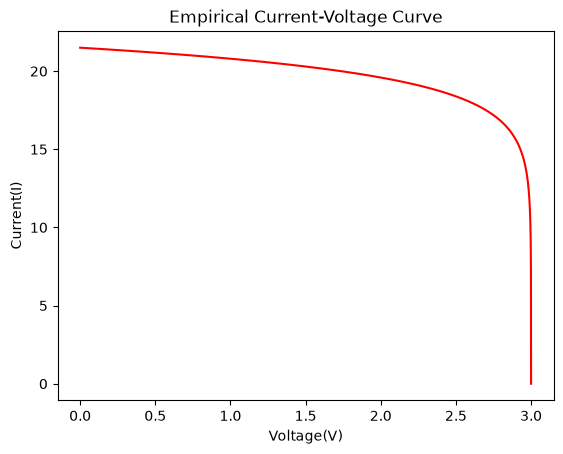

In [27]:
plt.plot(I,V,linestyle='solid',color='r')
plt.xlabel('Voltage(V)')
plt.ylabel('Current(I)')
plt.title("Empirical Current-Voltage Curve")

# Buck Converter Simulation

In [ ]:
def buck_converter(Vin,Iin,D):
    Vout = D*Vin
    Iout = Iinn/D

    Rin = Vout/Iout # This is 1/D^2 * Rout
    return Rin


# MPPT Algorithm Design

## IncCond

In [46]:
deltaI = np.diff(I)
deltaV = np.diff(V)

deltaD = 5e-5
epsilon = 1e-6
tolerance = 1e-6
D = 0.5*np.ones(np.size(deltaV))
for i in range(1,grid_resolution-1):
    if np.abs(deltaV[i])<tolerance:
        if np.abs(deltaI[i])<tolerance:
            pass
        elif deltaI[i] >0:
            D[i] +=deltaD
        else:
            D[i] -= deltaD
    else:
        dI_dV = deltaI[i]/deltaV[i]
        target = -I[i]/V[i]

        if np.abs(dI_dV - target)<epsilon:
            pass
        elif dI_dV>target:
            D[i] += deltaD
        else:
            D[i] -= deltaD

Rin = buck_converter(V,I,D)

ValueError: operands could not be broadcast together with shapes (4095,) (4096,) 